# Multi‑file Kurtogram + Order‑Spectrum Demo

This notebook processes all CSVs in `data/bearing_thl_v1`, one per speed and defect condition.

* **Goal**: show that, after envelope extraction and conversion to the order domain, fault signatures align across different speeds.
* **Steps per file**
  1. Compute spectral kurtosis; pick 2 kHz band.
  2. Band‑pass & Hilbert envelope.
  3. Envelope FFT → convert frequency axis to **order** by dividing by shaft speed (inferred from filename).

---

In [23]:
from pathlib import Path
import pandas as pd
import re
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt

from brf_lightning.utils.kurtogram import spectral_kurtosis, max_sk_band, plot_sk
from brf_lightning.data.bearing.utils import load_vibration_data

plt.rcParams['figure.dpi'] = 110


In [3]:
# ── Datei-Ablage ───────────────────────────────────────────────────
BASE_DIR      = Path("data/bearing_thl_v1")

# ── Kurtogramm / SK-Analyse ───────────────────────────────────────
NPERSEG_STFT  = 8192          # **vorher 1024 → echte ΔOrder ≈ 0.29**
BANDWIDTH_HZ  = 2000          # Suchbandbreite für SK-Maximum
MIN_FREQ_HZ   = 100.0         # min. Bandgrenze
MAX_RATIO_NQ  = 0.95          # max. Bandgrenze als Anteil Nyquist

# ── Hüllkurven-Spektrum ───────────────────────────────────────────
NFFT_ENV      = 65536         # **Zero-Padding für schlanke Peaks**
WINDOW_FN     = np.hanning    # Fenster über komplette Hüllkurve

# ── Regex-Extractor ───────────────────────────────────────────────
SPEED_RE      = re.compile(r"(\d+)\.csv$")      # captures 10 / 20 / 30
DEFECT_RE     = re.compile(r"^(n|fAII|fIII)")   # captures defect label


In [4]:
speed_re  = re.compile(r"(\d+)\.csv$")          # captures 10 / 20 / 30
defect_re = re.compile(r"^(n|fAII|fIII)")       # captures defect code

def get_speed(fp: Path) -> float:
    return float(speed_re.search(fp.name).group(1))

def get_defect(fp: Path) -> str:
    return defect_re.match(fp.stem).group(1)

## Helper: load and preprocess one file

In [5]:
results = {}

for fp in sorted(BASE_DIR.glob("*.csv")):
    # 1) Rohdaten laden -------------------------------------------------
    df, fs = load_vibration_data(fp)            # user-helper
    x      = df["sensor_bearing"].values.astype(np.float32)
    speed  = get_speed(fp)                      # Wellenfrequenz [Hz]
    defect = get_defect(fp)                     # Label
    
    # 2) Spektrale Kurtosis für bestes Resonanzband --------------------
    f, sk = spectral_kurtosis(
        x, fs,
        nperseg = NPERSEG_STFT                  # **längeres Fenster**
    )
    f_lo, f_hi = max_sk_band(
        f, sk,
        bandwidth = BANDWIDTH_HZ,
        min_freq  = MIN_FREQ_HZ,
        max_ratio = MAX_RATIO_NQ,
    )
    
    # 3) Schmalband-Filter + Hüllkurve ---------------------------------
    nyq = 0.5 * fs
    sos = sig.butter(4, [f_lo/nyq, f_hi/nyq], btype="bandpass", output="sos")
    xf  = sig.sosfiltfilt(sos, x)
    env = np.abs(sig.hilbert(xf))
    
    # 4) Order-Spektrum der Hüllkurve ----------------------------------
    #    Hinweis: Zero-Padding => optisch schmalere Peaks
    spec_c   = np.fft.rfft(env * WINDOW_FN(len(env)), n=NFFT_ENV)  # **n=NFFT_ENV**
    spec_mag = np.abs(spec_c)
    
    freq_Hz  = np.fft.rfftfreq(NFFT_ENV, d=1/fs)                   # **NFFT_ENV**
    orders   = freq_Hz / speed
    
    results[fp.name] = dict(
        defect = defect,
        speed  = speed,
        orders = orders,
        spec   = spec_mag,
    )

print(f"Processed {len(results)} traces")


Processed 9 traces


## Process all files

## Plot order spectra grouped by defect

In [ ]:
# Dateien nach Defekt gruppieren
defect_groups = {}
for fname in results:
    tag = fname.split("10")[0]          # crude grouping by prefix
    defect_groups.setdefault(tag, []).append(fname)

def plot_group(tag, fnames, xlim=(0, 10)):
    plt.figure(figsize=(6, 3))
    for fn in sorted(fnames):
        r = results[fn]
        plt.plot(r["orders"],
                 20*np.log10(r["spec"]+1e-6),
                 lw=0.8,
                 label=fn.split(".")[0])
    plt.xlim(*xlim)
    plt.ylim(bottom=-20)
    plt.xlabel("Order")
    plt.ylabel("Envelope amplitude [dB]")
    plt.title(f"Envelope Order Spectrum - {tag}")
    plt.grid(ls=":")
    plt.legend(fontsize=7)
    plt.tight_layout()


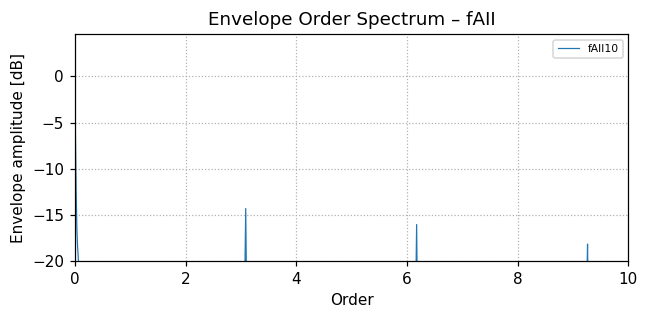

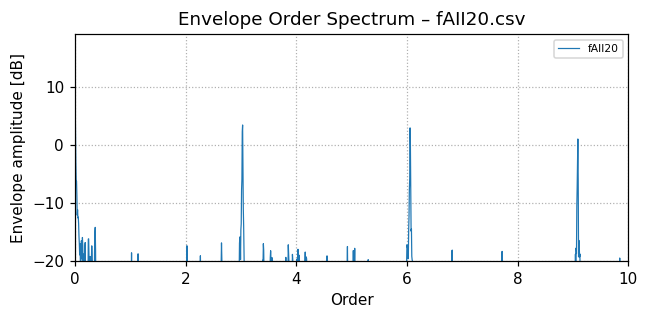

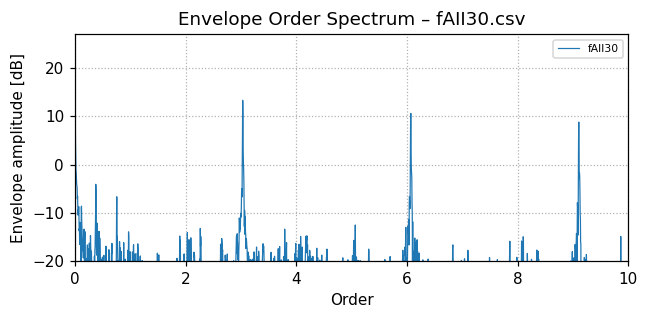

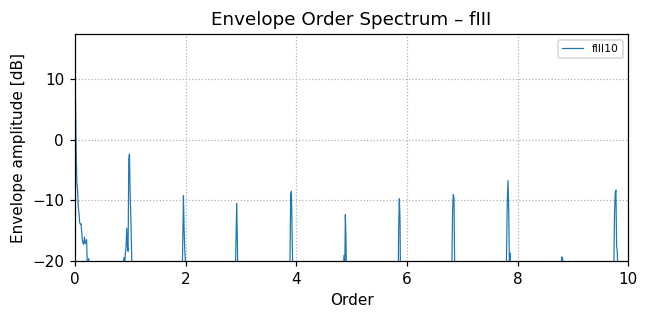

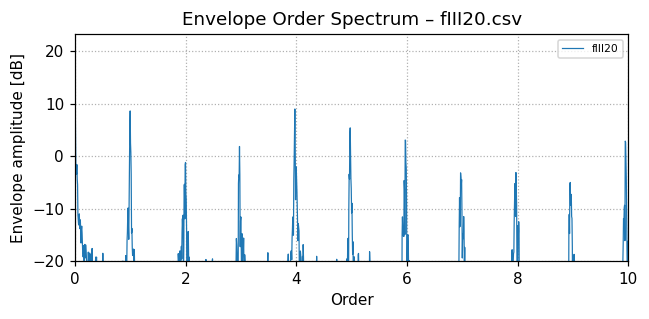

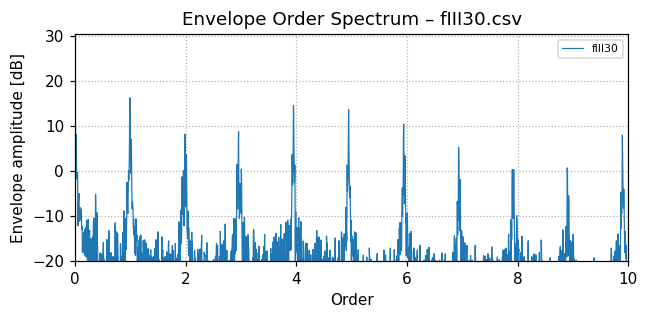

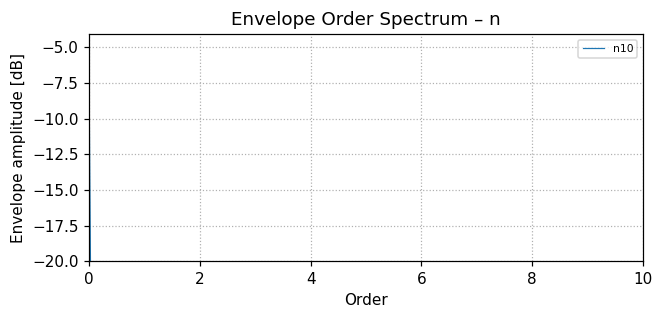

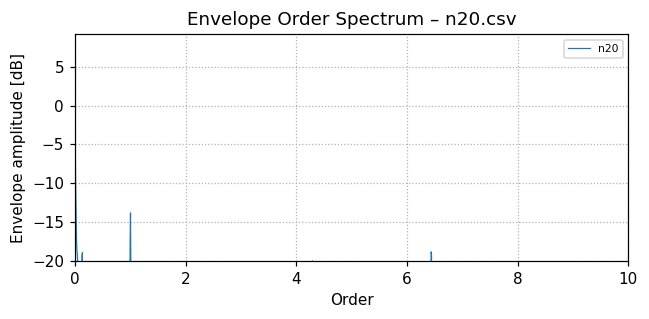

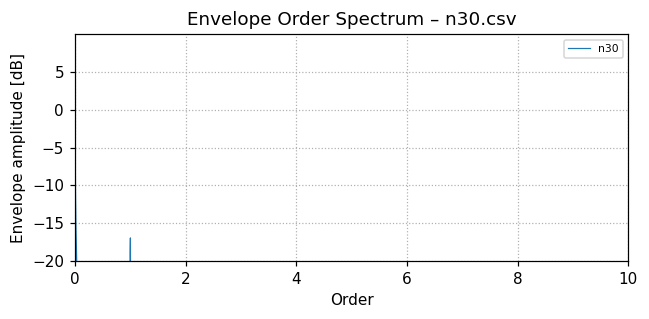

In [7]:
for defect, fnames in defect_groups.items():
    plot_group(defect, fnames)

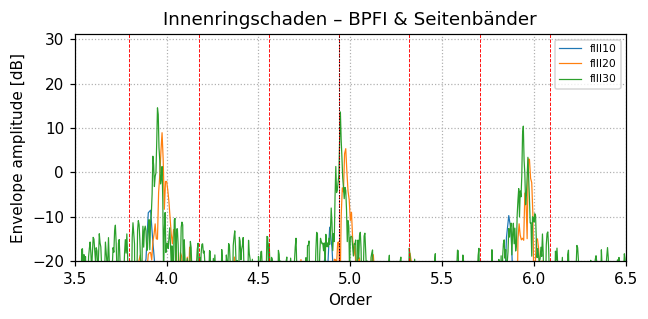

In [8]:
# ── Parameter nur für die "Innenring"-Analyse ──────────────────────
TARGET_DEFECT = "fIII"       # Innenringschaden
CENTER_ORDER  = 4.94         # BPFI-Theorie
SIDE_STEP     = 0.382        # FTF-Theorie
HARMONICS     = 2            # bis 2·BPFI anzeigen
ZOOM_RANGE    = (3.5, 6.5)   # Plot­fenster

# ── Alle Spuren mit Innenringschaden filtern ───────────────────────
inner_files = [fn for fn in results if results[fn]["defect"] == TARGET_DEFECT]

plt.figure(figsize=(6, 3))
for fn in sorted(inner_files):
    r = results[fn]
    plt.plot(r["orders"], 20*np.log10(r["spec"]+1e-6),
             lw=0.8, label=fn.split(".")[0])

# ── Soll-Linien einzeichnen ----------------------------------------
for n in range(-3, 4):                       # Seitenbänder ±3
    plt.axvline(CENTER_ORDER + n*SIDE_STEP,
                c="red", ls="--", lw=0.6)
for h in range(1, HARMONICS+1):              # Harmonische
    plt.axvline(h*CENTER_ORDER, c="black", ls=":", lw=0.7)

plt.xlim(*ZOOM_RANGE)
plt.ylim(bottom=-20)
plt.xlabel("Order")
plt.ylabel("Envelope amplitude [dB]")
plt.title("Innenringschaden – BPFI & Seitenbänder")
plt.grid(ls=":")
plt.legend(fontsize=7)
plt.tight_layout()


In [9]:
# --- Peak-Tracing über alle Geschwindigkeiten -----------------------
import numpy as np
from scipy.signal import find_peaks
import pandas as pd
from collections import defaultdict

# Fenster für automatische Suche
WINDOWS = {
    'BPFI':  (4.5, 5.3),
    'SB_L':  (3.6, 3.9),   # Seitenband links (n = -3)
    'SB_R':  (5.9, 6.2),   # Seitenband rechts (n = +3)
}

records = defaultdict(list)

for fn, r in results.items():
    shaft = r['speed']
    o     = r['orders']
    a_db  = 20*np.log10(r['spec'] + 1e-6)

    for label, (lo, hi) in WINDOWS.items():
        idx = np.where((o >= lo) & (o <= hi))[0]
        if len(idx) == 0: 
            continue
        # stärksten Peak im Fenster suchen
        pks, _ = find_peaks(a_db[idx])
        if len(pks) == 0:
            continue
        pk_idx  = idx[pks[np.argmax(a_db[idx][pks])]]
        f_peak  = o[pk_idx] * shaft      # absolut in Hz
        order   = o[pk_idx]
        records[label].append(
            dict(file=fn, shaft=shaft, f_peak=f_peak, order=order)
        )

# --- Analyse & Report ----------------------------------------------
df = {k: pd.DataFrame(v) for k, v in records.items()}

for label, tbl in df.items():
    slope, _ = np.polyfit(tbl['shaft'], tbl['f_peak'], deg=1)
    sigma    = tbl['order'].std()
    print(f"{label}: slope={slope/1:.3f}  (Soll {WINDOWS[label]})  "
          f"σ(Order)={sigma:.3f}")


BPFI: slope=5.148  (Soll (4.5, 5.3))  σ(Order)=0.183
SB_L: slope=3.827  (Soll (3.6, 3.9))  σ(Order)=0.074
SB_R: slope=6.023  (Soll (5.9, 6.2))  σ(Order)=0.087


In [14]:
results.keys()

dict_keys(['fAII10.csv', 'fAII20.csv', 'fAII30.csv', 'fIII10.csv', 'fIII20.csv', 'fIII30.csv', 'n10.csv', 'n20.csv', 'n30.csv'])

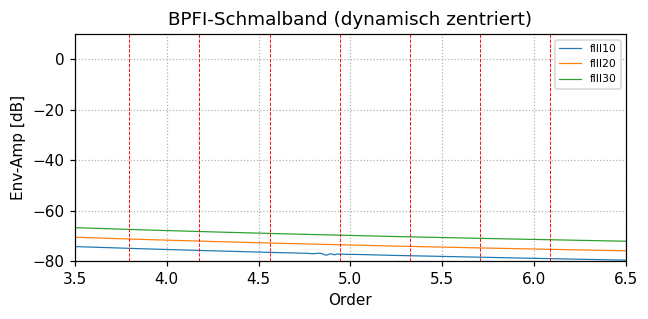

,file,shaft,order
0,fIII10.csv,10.0,3.5
1,fIII20.csv,20.0,3.5
2,fIII30.csv,30.0,3.5


In [18]:
## 8  Inside-Band-Check: dynamischer BPFI-Bandpass

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, hilbert, find_peaks

BPFI_ORDER   = 4.942        # Herstellerwert (siehe Screenshot)
BW_HZ        = 2.0          # Gesamtbreite (±1 Hz)
WINDOW_FN    = np.hanning
NFFT_BPFI    = 65536
ORDER_RANGE  = (3.5, 6.5)

records = []
plt.figure(figsize=(6, 3))

for fn, r in results.items():
    if r["defect"] != "fIII":         # nur Innenring-Schäden
        continue

    shaft = r["speed"]               # 10 / 20 / 30 Hz
    f_c   = BPFI_ORDER * shaft       # **↺ dynamische Mittenfreq.**
    nyq   = 0.5 * fs
    f_lo, f_hi = (f_c - BW_HZ/2)/nyq, (f_c + BW_HZ/2)/nyq
    sos   = butter(4, [f_lo, f_hi], btype="bandpass", output="sos")

    # Weg: absoluter Pfad, nicht nur Dateiname
    x = load_vibration_data(Path("data") / "bearing_thl_v1" / fn)[0]["sensor_bearing"].values.astype(np.float32)

    env = np.abs(hilbert(sosfiltfilt(sos, x)))
    spec = np.fft.rfft(env * WINDOW_FN(len(env)), n=NFFT_BPFI)
    freq = np.fft.rfftfreq(NFFT_BPFI, d=1/fs)
    orders = freq / shaft

    # stärkster Peak in der Order-Range
    idx = np.where((orders >= ORDER_RANGE[0]) & (orders <= ORDER_RANGE[1]))[0]
    if idx.size:
        pk = idx[np.argmax(np.abs(spec[idx]))]
        records.append(dict(file=fn, shaft=shaft, order=orders[pk]))

    plt.plot(orders[idx],
             20*np.log10(np.abs(spec[idx]) + 1e-9),
             lw=.8, label=fn.split('.')[0])

# Soll-Linien
for n in range(-3, 4):
    plt.axvline(BPFI_ORDER + n*0.382, c="red", ls="--", lw=.6)

plt.xlim(*ORDER_RANGE)
plt.ylim(-80, 10)           # **breiter Dynamikbereich**
plt.xlabel("Order"), plt.ylabel("Env-Amp [dB]")
plt.title("BPFI-Schmalband (dynamisch zentriert)")
plt.grid(ls=":")
plt.legend(fontsize=7), plt.tight_layout()
plt.show()

pk_df = pd.DataFrame(records)
display(pk_df)


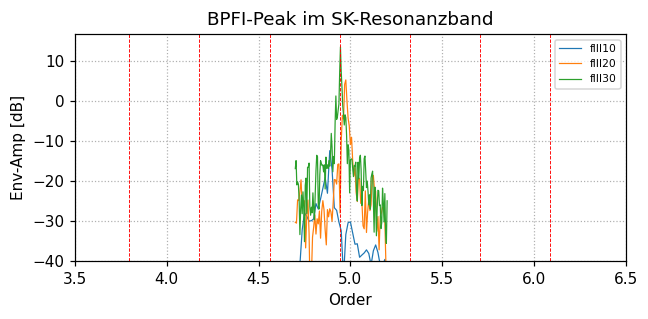

         file  shaft     order
0  fIII10.csv   10.0  4.887500
1  fIII20.csv   20.0  4.975000
2  fIII30.csv   30.0  4.945833
σ(Order) = 0.0445528192565149


In [19]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import find_peaks

BPFI_ORDER = 4.942
FTF_ORDER  = 0.382
ORDER_RANGE = (3.5, 6.5)       # zum Plotten / Peak-Suche

records = []
plt.figure(figsize=(6,3))

for fn, r in results.items():
    if r["defect"] != "fIII":      # nur Innenring-Schäden
        continue

    orders = r["orders"]           # stammen aus deiner SK-Pipeline
    spec   = r["spec"]             # dito  (Envelope-Spektrum)
    shaft  = r["speed"]

    # strongest peak in the BPFI window
    win = np.where((orders>=4.7) & (orders<=5.2))[0]
    if win.size:
        pk = win[np.argmax(spec[win])]
        records.append(dict(file=fn, shaft=shaft, order=orders[pk]))
    
    plt.plot(orders[win],
             20*np.log10(spec[win]+1e-9),
             lw=.8, label=fn.split('.')[0])

# Soll-Linien
for n in range(-3,4):
    plt.axvline(BPFI_ORDER+n*FTF_ORDER, c='red', ls='--', lw=.6)

plt.xlim(*ORDER_RANGE); plt.ylim(bottom=-40)
plt.xlabel("Order"); plt.ylabel("Env-Amp [dB]")
plt.title("BPFI-Peak im SK-Resonanzband")
plt.grid(ls=":"); plt.legend(fontsize=7); plt.tight_layout()
plt.show()

df = pd.DataFrame(records)
print(df)
print("σ(Order) =", df["order"].std())


In [20]:
MED_WIN_REV   = 5                      # Median über 5 Umdr.
NARROW_BW_HZ  = 1000                   # ±0,5 kHz Bandpass
NFFT_ENV_FINE = 131_072                # 2× vorher
BPFI_ORDER    = 4.942
FTF_ORDER     = 0.382

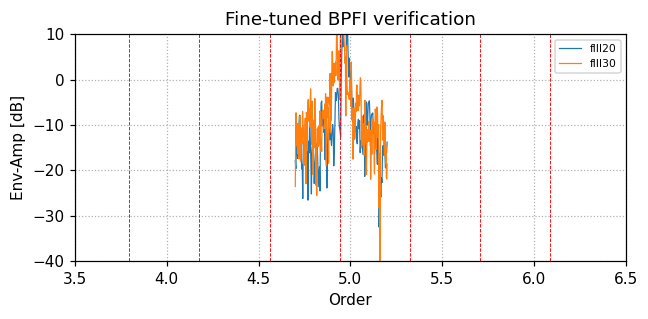

         file  shaft     order
0  fIII20.csv   20.0  4.971875
1  fIII30.csv   30.0  4.952083
σ(Order) = 0.013994821710983586


In [29]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import scipy.signal as sig
from brf_lightning.utils.kurtogram import spectral_kurtosis   # ← deine Lib

BASE_DIR      = Path("data/bearing_thl_v1")
DEFECT_LABEL  = "fIII"
BPFI_ORDER    = 4.942
FTF_ORDER     = 0.382
SEARCH_WIN    = (4.7, 5.2)
ORDER_PLOT    = (3.5, 6.5)
BANDWIDTH_HZ  = 1_000
NFFT_ENV      = 131_072
WINDOW_FN     = np.hanning
MIN_RESONANCE_HZ = 1_000
MAX_RESON_RATIO  = 0.95          # 95 % von Nyquist

# -----------------------------------------------------------
def best_resonance_band(x, fs, bw_hz=BANDWIDTH_HZ):
    f, sk = spectral_kurtosis(x, fs, nperseg=8192)
    mask = (f > MIN_RESONANCE_HZ) & (f < fs*0.5*MAX_RESON_RATIO)
    return f[mask][np.argmax(sk[mask])]

def envelope_hilbert(x, fs, centre_hz, bw_hz=BANDWIDTH_HZ):
    nyq = 0.5 * fs
    lo  = max(10.0, centre_hz - bw_hz/2)
    hi  = min(nyq*MAX_RESON_RATIO, centre_hz + bw_hz/2)
    sos = sig.butter(4, [lo/nyq, hi/nyq], btype='bandpass', output='sos')
    return np.abs(sig.hilbert(sig.sosfiltfilt(sos, x)))
# -----------------------------------------------------------

records = []
plt.figure(figsize=(6,3))

for fp in sorted(BASE_DIR.glob(f"{DEFECT_LABEL}*.csv")):
    df, fs = load_vibration_data(fp)
    x   = df["sensor_bearing"].values.astype(np.float32)
    rpm = float(fp.stem.split(DEFECT_LABEL)[-1])        # 10 / 20 / 30
    f_shaft = rpm

    centre = best_resonance_band(x, fs)
    env    = envelope_hilbert(x, fs, centre)

    spec   = np.fft.rfft(env * WINDOW_FN(len(env)), n=NFFT_ENV)
    freq   = np.fft.rfftfreq(NFFT_ENV, d=1/fs)
    orders = freq / f_shaft

    win = np.where((orders >= SEARCH_WIN[0]) & (orders <= SEARCH_WIN[1]))[0]
    pk  = win[np.argmax(np.abs(spec[win]))]
    records.append(dict(file=fp.name, shaft=f_shaft, order=orders[pk]))

    plt.plot(orders[win], 20*np.log10(np.abs(spec[win]) + 1e-9),
             lw=.8, label=fp.stem)

for n in range(-3,4):
    plt.axvline(BPFI_ORDER+n*FTF_ORDER, c='red', ls='--', lw=.6)

plt.xlim(*ORDER_PLOT); plt.ylim(-40,10)
plt.xlabel("Order"); plt.ylabel("Env-Amp [dB]")
plt.title("Fine-tuned BPFI verification")
plt.grid(ls=":"); plt.legend(fontsize=7); plt.tight_layout(); plt.show()

df_res = pd.DataFrame(records)
print(df_res)
print("σ(Order) =", df_res["order"].std())
